# Bayesian Logistic Regression: Random-Walk MCMC vs HMC

Run in order: **Data → Model → Sampling → Evaluation → Visualization**.

Compare **symmetric random-walk Metropolis** with **Hamiltonian Monte Carlo (HMC)** on the same Bayesian logistic-regression posterior.

The main question is: **what changes when the sampler uses gradient information?**

## 1. Data

Generate a small binary classification dataset.

We use one input feature and an intercept, so the parameter vector is
\[
w=(w_0,w_1)^\top\in\mathbb R^2.
\]

Keeping the posterior two-dimensional lets us visualize both the posterior and the MCMC trajectories.

In [1]:
import torch
import matplotlib.pyplot as plt

# ============================================================
# 1. Generate binary classification data
# ============================================================
torch.manual_seed(0)

N = 80

x = 1.3 * torch.randn(N, 1)
phi = torch.cat([torch.ones(N, 1), x], dim=1)

w_true = torch.tensor([-0.5, 2.0])
prob_true = torch.sigmoid(phi @ w_true)
y = torch.bernoulli(prob_true)

D = phi.shape[1]

print(f"Number of observations: {N}")
print(f"Number of parameters: {D}")

Number of observations: 80
Number of parameters: 2


### View the dataset

Each point is an observation \((x_i,y_i)\).

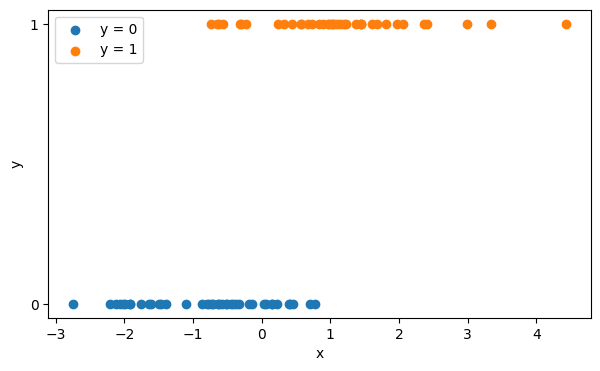

In [2]:
plt.figure(figsize=(7, 4))
plt.scatter(x[y == 0], y[y == 0], label="y = 0")
plt.scatter(x[y == 1], y[y == 1], label="y = 1")

plt.xlabel("x")
plt.ylabel("y")
plt.yticks([0, 1])
plt.legend()
plt.show()

## 2. Model

For Bayesian logistic regression,

$$
p(y_i=1 \mid \mathbf{x}_i,\mathbf{w})
=
\sigma(\mathbf{w}^\top \boldsymbol{\phi}_i).
$$

Use a Gaussian prior

$$
p(\mathbf{w})
=
\mathcal{N}(\mathbf{0}, \sigma_0^2 \mathbf{I}).
$$

The unnormalized log posterior is

$$
\log \widetilde{p}(\mathbf{w}\mid\mathcal{D})
=
-\frac{1}{2\sigma_0^2}\mathbf{w}^\top\mathbf{w}
+
\sum_{i=1}^{N}
\left[
y_i a_i-\log(1+e^{a_i})
\right],
\qquad
a_i=\mathbf{w}^\top\boldsymbol{\phi}_i.
$$

Both samplers below target the **same posterior**.

In [3]:
# ============================================================
# 2. Bayesian logistic regression posterior
# ============================================================
prior_std = 3.0

def log_posterior(w):
    logits = phi @ w

    log_likelihood = (
        y * logits - torch.logaddexp(torch.zeros_like(logits), logits)
    ).sum()

    log_prior = -0.5 * (w @ w) / prior_std**2

    return log_prior + log_likelihood


def energy(w):
    # Potential energy used by HMC
    return -log_posterior(w)


def grad_energy(w):
    # Gradient of E(w) = -log p~(w | D)
    prob = torch.sigmoid(phi @ w)

    grad_prior = w / prior_std**2
    grad_likelihood = phi.T @ (prob - y)

    return grad_prior + grad_likelihood

### Posterior distribution

Because \(w\in\mathbb R^2\), we can directly draw the posterior contours.

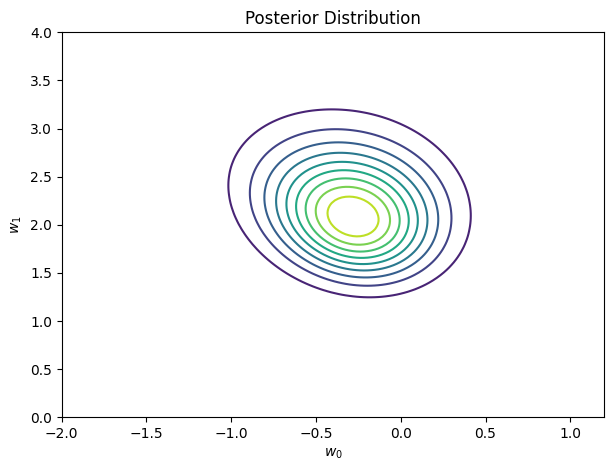

In [4]:
# ============================================================
# Posterior grid for visualization
# ============================================================
w0_values = torch.linspace(-2.0, 1.2, 150)
w1_values = torch.linspace(0.0, 4.0, 150)

W0, W1 = torch.meshgrid(w0_values, w1_values, indexing="xy")
posterior = torch.zeros_like(W0)

for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        w_grid = torch.tensor([W0[i, j], W1[i, j]])
        posterior[i, j] = log_posterior(w_grid)

posterior = torch.exp(posterior - posterior.max())

plt.figure(figsize=(7, 5))
plt.contour(W0, W1, posterior, levels=10)
plt.xlabel(r"$w_0$")
plt.ylabel(r"$w_1$")
plt.title("Posterior Distribution")
plt.show()

## 3. Sampling

We now generate samples from \(p(w\mid\mathcal D)\) using two MCMC methods.

### 3.1 Symmetric Random-Walk Metropolis

Use the proposal
$$
w'=w+\xi,
\qquad
\xi\sim\mathcal N(0,s^2I).
$$

Since the proposal is symmetric,
$$
A(w,w')
=
\min\left(
1,\frac{\widetilde p(w'\mid\mathcal D)}
        {\widetilde p(w\mid\mathcal D)}
\right).
$$

The proposal uses the current state, but **does not use the gradient of the posterior**.

In [5]:
# ============================================================
# 3.1 Symmetric random-walk Metropolis
# ============================================================
def random_walk_mcmc(w_init, num_samples, proposal_std):
    w = w_init.clone()
    samples = []
    accepted = 0

    for t in range(num_samples):

        # Random local proposal
        w_proposal = w + proposal_std * torch.randn_like(w)

        # Log acceptance ratio
        log_ratio = log_posterior(w_proposal) - log_posterior(w)

        # Accept / reject
        if torch.log(torch.rand(1)) < torch.minimum(
            torch.tensor(0.0), log_ratio
        ):
            w = w_proposal
            accepted += 1

        samples.append(w.clone())

    samples = torch.stack(samples)
    acceptance_rate = accepted / num_samples

    return samples, acceptance_rate


num_samples = 4000

rw_samples, rw_acceptance = random_walk_mcmc(
    w_init=torch.zeros(D),
    num_samples=num_samples,
    proposal_std=0.30,
)

print(f"Random-walk acceptance rate: {rw_acceptance:.3f}")

Random-walk acceptance rate: 0.619


### 3.2 Hamiltonian Monte Carlo

HMC introduces momentum with mass matrix $M=0.1^2 I$:
$$
r\sim\mathcal N(0,M),\qquad M^{-1}=100I.
$$
The Hamiltonian is
$$
H(w,r)=E(w)+\frac12r^\top M^{-1}r
=E(w)+\frac{100}{2}r^\top r.
$$

Hamiltonian dynamics use the posterior gradient:
$$
\frac{dw}{d\tau}=M^{-1}r=100r,
\qquad
\frac{dr}{d\tau}=-\nabla E(w).
$$

We approximate the trajectory using **\(L\) leapfrog steps** with step size \(\epsilon\).
`momentum_std = 0.1` defines the mass matrix; its inverse must appear in both the kinetic energy and the position update. The momentum update is unchanged.

We use `step_size = 0.008` instead of `0.08`: scaling the mass from $I$ to $0.1^2 I$ increases the dynamics' frequency by a factor of ten, so we reduce the step size by the same factor.


In [6]:
# ============================================================
# 3.2 Leapfrog integration
# ============================================================
momentum_std = 0.1
mass = momentum_std ** 2  # M = mass * I
inv_mass = 1.0 / mass


def leapfrog(w, r, step_size, num_steps):
    w = w.clone()
    r = r.clone()

    for l in range(num_steps):

        # Momentum: half step
        r = r - 0.5 * step_size * grad_energy(w)

        # Position: full step using velocity M^{-1} r
        w = w + step_size * inv_mass * r

        # Momentum: half step
        r = r - 0.5 * step_size * grad_energy(w)

    return w, r


def hamiltonian(w, r):
    kinetic_energy = 0.5 * inv_mass * (r @ r)
    return energy(w) + kinetic_energy

### HMC sampling

At each MCMC iteration:

1. Sample a fresh momentum \(r\sim\mathcal N(0,M)\).
2. Follow the gradient-informed trajectory for \(L\) leapfrog steps.
3. Accept or reject the endpoint using the Hamiltonian difference.

In [7]:
# ============================================================
# HMC
# ============================================================
def hmc(w_init, num_samples, step_size, num_steps):
    w = w_init.clone()
    samples = []
    accepted = 0

    for t in range(num_samples):

        # Sample fresh momentum from N(0, M)
        r = momentum_std * torch.randn_like(w)

        current_w = w.clone()
        current_r = r.clone()

        # Gradient-informed proposal
        proposed_w, proposed_r = leapfrog(
            current_w, current_r, step_size, num_steps
        )

        # Hamiltonian difference
        current_H = hamiltonian(current_w, current_r)
        proposed_H = hamiltonian(proposed_w, proposed_r)

        log_ratio = current_H - proposed_H

        # Accept / reject
        if torch.log(torch.rand(1)) < torch.minimum(
            torch.tensor(0.0), log_ratio
        ):
            w = proposed_w
            accepted += 1

        samples.append(w.clone())

    samples = torch.stack(samples)
    acceptance_rate = accepted / num_samples

    return samples, acceptance_rate


hmc_samples, hmc_acceptance = hmc(
    w_init=torch.zeros(D),
    num_samples=num_samples,
    step_size=0.008,
    num_steps=12,
)

print(f"HMC acceptance rate: {hmc_acceptance:.3f}")

HMC acceptance rate: 0.996


## 4. Evaluation

Discard the initial burn-in samples.

We compare:

- acceptance rate,
- posterior mean,
- autocorrelation of the sampled parameters.

Lower autocorrelation indicates faster exploration of the posterior.

In [8]:
# ============================================================
# 4. Evaluation
# ============================================================
burn_in = 500

rw_post = rw_samples[burn_in:]
hmc_post = hmc_samples[burn_in:]

print("Random-Walk Metropolis")
print(f"  acceptance rate : {rw_acceptance:.3f}")
print(f"  posterior mean  : {rw_post.mean(dim=0).numpy()}")

print("\nHamiltonian Monte Carlo")
print(f"  acceptance rate : {hmc_acceptance:.3f}")
print(f"  posterior mean  : {hmc_post.mean(dim=0).numpy()}")

Random-Walk Metropolis
  acceptance rate : 0.619
  posterior mean  : [-0.30296504  2.2244723 ]

Hamiltonian Monte Carlo
  acceptance rate : 0.996
  posterior mean  : [-0.29524282  2.2101479 ]


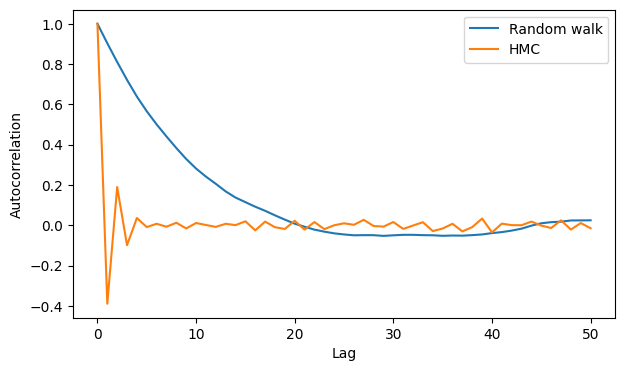

In [10]:
def autocorrelation(x, max_lag=50):
    x = x - x.mean()
    variance = (x * x).sum()

    values = []

    for lag in range(max_lag + 1):
        if lag == 0:
            values.append(torch.tensor(1.0))
        else:
            covariance = (x[:-lag] * x[lag:]).sum()
            values.append(covariance / variance)

    return torch.stack(values)


max_lag = 50

rw_acf = autocorrelation(rw_post[:, 1], max_lag)
hmc_acf = autocorrelation(hmc_post[:, 1], max_lag)

plt.figure(figsize=(7, 4))
plt.plot(rw_acf, label="Random walk")
plt.plot(hmc_acf, label="HMC")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.legend()
plt.show()

## 5. Visualization

The first comparison shows the **early MCMC trajectories** on the posterior contours.

Random-walk Metropolis makes short local moves.  
HMC uses the posterior gradient to construct longer, directed moves.

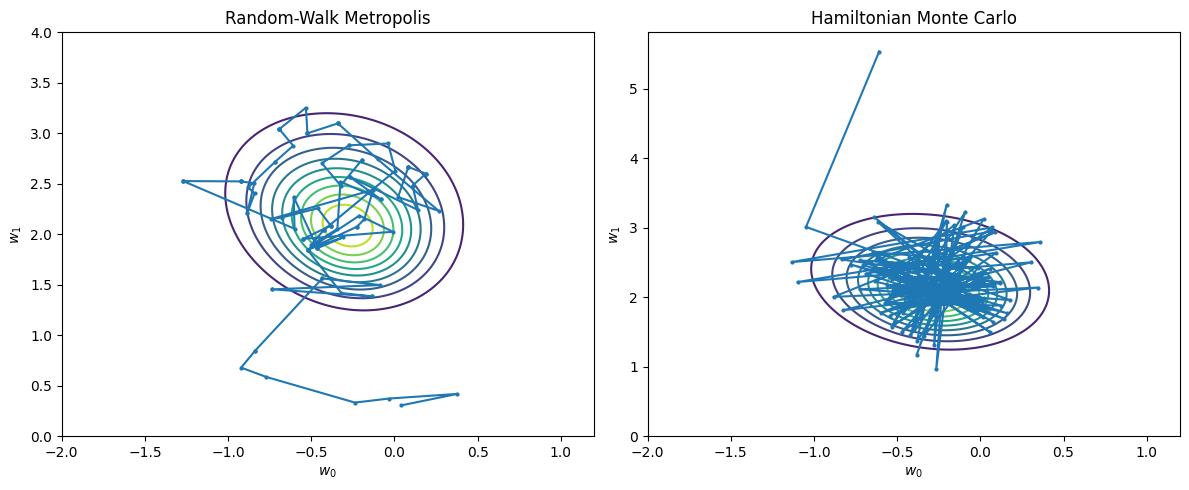

In [11]:
# ============================================================
# 5. Compare sampling trajectories
# ============================================================
num_show = 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].contour(W0, W1, posterior, levels=10)
axes[0].plot(
    rw_samples[:num_show, 0],
    rw_samples[:num_show, 1],
    "-o",
    markersize=2,
)
axes[0].set_title("Random-Walk Metropolis")
axes[0].set_xlabel(r"$w_0$")
axes[0].set_ylabel(r"$w_1$")

axes[1].contour(W0, W1, posterior, levels=10)
axes[1].plot(
    hmc_samples[:num_show, 0],
    hmc_samples[:num_show, 1],
    "-o",
    markersize=2,
)
axes[1].set_title("Hamiltonian Monte Carlo")
axes[1].set_xlabel(r"$w_0$")
axes[1].set_ylabel(r"$w_1$")

plt.tight_layout()
plt.show()

### Posterior samples

After burn-in, both methods should represent the same posterior.

The difference is **how efficiently they explore it**.

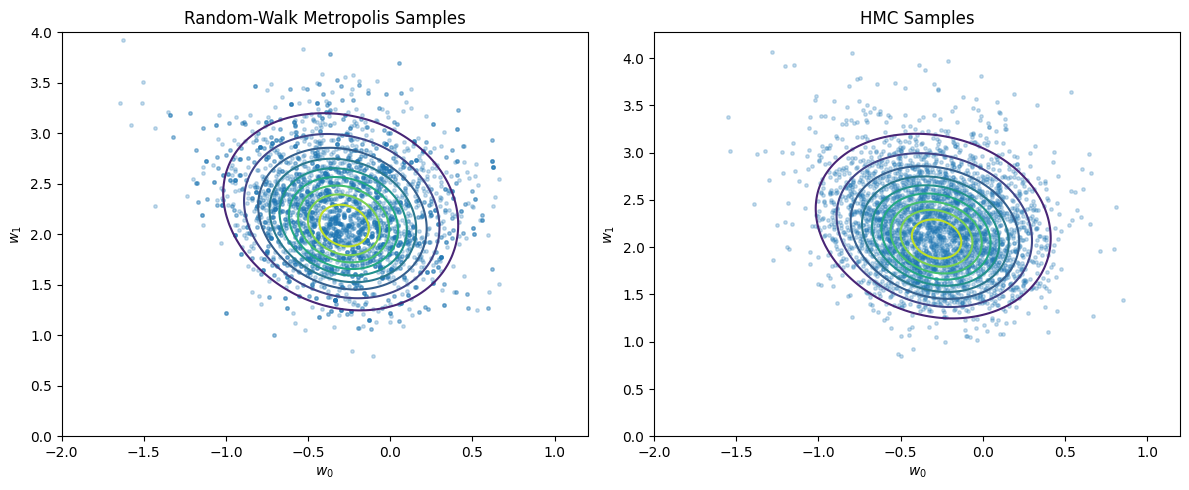

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].contour(W0, W1, posterior, levels=10)
axes[0].scatter(
    rw_post[:, 0],
    rw_post[:, 1],
    s=6,
    alpha=0.25,
)
axes[0].set_title("Random-Walk Metropolis Samples")
axes[0].set_xlabel(r"$w_0$")
axes[0].set_ylabel(r"$w_1$")

axes[1].contour(W0, W1, posterior, levels=10)
axes[1].scatter(
    hmc_post[:, 0],
    hmc_post[:, 1],
    s=6,
    alpha=0.25,
)
axes[1].set_title("HMC Samples")
axes[1].set_xlabel(r"$w_0$")
axes[1].set_ylabel(r"$w_1$")

plt.tight_layout()
plt.show()

### Trace plot

A slowly mixing chain tends to remain near its previous state.

HMC should typically move across the posterior more rapidly because its proposals use gradient information.

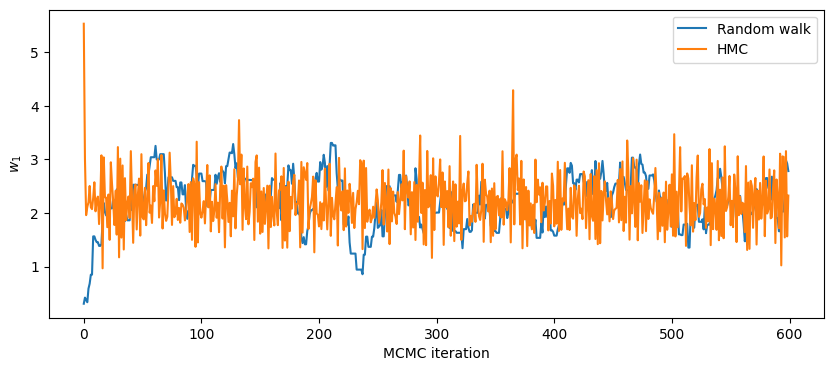

In [13]:
num_show = 600

plt.figure(figsize=(10, 4))
plt.plot(rw_samples[:num_show, 1], label="Random walk")
plt.plot(hmc_samples[:num_show, 1], label="HMC")

plt.xlabel("MCMC iteration")
plt.ylabel(r"$w_1$")
plt.legend()
plt.show()

## Main observation

$$
\boxed{
\text{Random walk: random local proposal}
\qquad\text{vs.}\qquad
\text{HMC: gradient-informed trajectory}
}
$$

Both methods use an MCMC accept/reject correction and target the same Bayesian posterior.

The difference is the **proposal mechanism**: HMC uses
$$
\nabla E(w)
$$
to move through the posterior more efficiently.

## 6. Prediction

After obtaining posterior samples, Bayesian prediction averages predictions over the posterior:

$$
p(y_*=1\mid x_*,\mathcal D)
\approx
\frac{1}{S}
\sum_{s=1}^{S}
\sigma\left(
(\mathbf{w}^{(s)})^\top\boldsymbol{\phi}_*
\right).
$$

We compare posterior predictive probabilities obtained from
**Random-Walk Metropolis** and **HMC**.

In [14]:
# ============================================================
# 6. Posterior predictive distribution
# ============================================================

def posterior_predictive_samples(samples, x_test):
    phi_test = torch.cat([
        torch.ones(len(x_test), 1),
        x_test.reshape(-1, 1)
    ], dim=1)

    # Each posterior sample gives one predictive probability curve
    logits = samples @ phi_test.T
    probs = torch.sigmoid(logits)

    return probs


x_test = torch.linspace(-4, 4, 200)

rw_pred_samples = posterior_predictive_samples(rw_post, x_test)
hmc_pred_samples = posterior_predictive_samples(hmc_post, x_test)

rw_pred = rw_pred_samples.mean(dim=0)
hmc_pred = hmc_pred_samples.mean(dim=0)

### Posterior predictive mean

Both samplers target the same posterior, so their posterior predictive probabilities should be similar when the chains have mixed sufficiently.

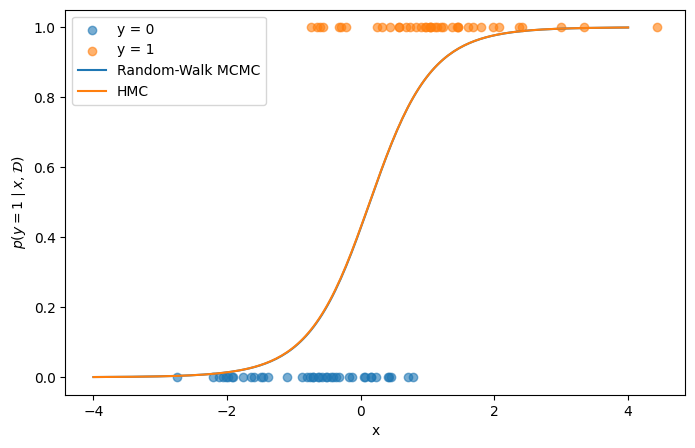

In [15]:
plt.figure(figsize=(8, 5))

# Training data
plt.scatter(
    x[y == 0], y[y == 0],
    label="y = 0",
    alpha=0.6
)

plt.scatter(
    x[y == 1], y[y == 1],
    label="y = 1",
    alpha=0.6
)

# Posterior predictive probabilities
plt.plot(
    x_test,
    rw_pred,
    label="Random-Walk MCMC"
)

plt.plot(
    x_test,
    hmc_pred,
    label="HMC"
)

plt.xlabel("x")
plt.ylabel(r"$p(y=1 \mid x, \mathcal{D})$")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.show()

### Predictive uncertainty

Each posterior sample gives a different predictive probability

$$
p_*^{(s)}
=
\sigma\left(
(\mathbf{w}^{(s)})^\top\boldsymbol{\phi}_*
\right).
$$

The variation across posterior samples represents uncertainty about the model parameters.

Below, we visualize the HMC posterior predictive mean and a **90% posterior interval** of the predicted probability.

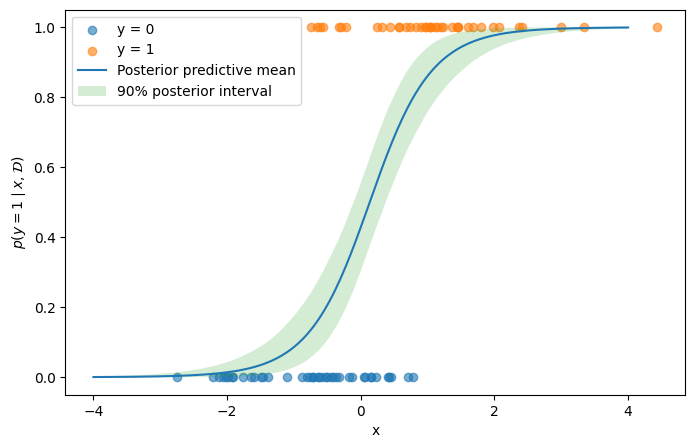

In [16]:
# ============================================================
# Predictive uncertainty from HMC posterior samples
# ============================================================

pred_mean = hmc_pred_samples.mean(dim=0)
pred_lower = torch.quantile(hmc_pred_samples, 0.05, dim=0)
pred_upper = torch.quantile(hmc_pred_samples, 0.95, dim=0)

plt.figure(figsize=(8, 5))

plt.scatter(
    x[y == 0], y[y == 0],
    label="y = 0",
    alpha=0.6
)

plt.scatter(
    x[y == 1], y[y == 1],
    label="y = 1",
    alpha=0.6
)

plt.plot(
    x_test,
    pred_mean,
    label="Posterior predictive mean"
)

plt.fill_between(
    x_test,
    pred_lower,
    pred_upper,
    alpha=0.2,
    label="90% posterior interval"
)

plt.xlabel("x")
plt.ylabel(r"$p(y=1 \mid x, \mathcal{D})$")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.show()

## Main Observation

Both Random-Walk Metropolis and HMC target the same Bayesian logistic-regression posterior.

$$
\boxed{
\text{Random walk: random local proposal}
\qquad\text{vs.}\qquad
\text{HMC: gradient-informed trajectory}
}
$$

Random-Walk Metropolis proposes local moves without using the posterior geometry.

HMC uses

$$
\nabla E(\mathbf{w})
$$

to construct longer, directed proposals. This can reduce autocorrelation and improve posterior exploration.

Once posterior samples are obtained, **both methods use the same Bayesian prediction rule**:

$$
\text{sample the posterior}
\quad\Longrightarrow\quad
\text{average predictions}.
$$